In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
data = pd.read_csv('../data/clean_data.csv')
data.shape

(10000, 8)

In [3]:
docs_clean = data['clean_text'].fillna('').tolist()
docs_tokens = [d.split() for d in docs_clean]
len(docs_clean)

10000

In [4]:
# Cell 4 - TF-IDF
vectorizer = CountVectorizer(max_features=10000, min_df=5, max_df=0.95)
dtm = vectorizer.fit_transform(docs_clean)
vocab = vectorizer.get_feature_names_out()
dtm.shape

(10000, 5198)

In [5]:
lda = LatentDirichletAllocation(n_components=20, random_state=42,
                                 max_iter=20, learning_method='online')
lda.fit(dtm)

,n_components,20
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'online'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,20
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [6]:
for i, topic in enumerate(lda.components_[:10]):
    top_words = [vocab[j] for j in topic.argsort()[-8:][::-1]]
    print(f"Topic {i}: {', '.join(top_words)}")

Topic 0: find, study, may, death, making, list, top, child
Topic 1: life, way, health, good, time, could, care, body
Topic 2: like, one, day, dont, get, really, think, people
Topic 3: feel, wedding, make, show, know, need, news, photo
Topic 4: make, want, photo, style, twitter, let, facebook, new
Topic 5: woman, come, every, home, food, something, still, end
Topic 6: man, star, another, boy, lead, hollywood, reportedly, iraq
Topic 7: medium, company, court, use, social, national, benefit, age
Topic 8: gop, republican, here, deal, would, community, he, others
Topic 9: new, house, never, white, city, week, york, people


In [7]:
!pip install gensim -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

lda_topics = [[vocab[j] for j in t.argsort()[-10:][::-1]]
              for t in lda.components_]

dictionary = Dictionary(docs_tokens)

lda_cm = CoherenceModel(topics=lda_topics, texts=docs_tokens,
                        dictionary=dictionary, coherence='c_v')
LDA_SCORE = lda_cm.get_coherence()
LDA_PERPLEXITY = lda.perplexity(dtm)

print(f'Coherence Score: {LDA_SCORE:.4f}')
print(f'Perplexity Score: {LDA_PERPLEXITY:.4f}')


np.float64(0.35738443778737833)

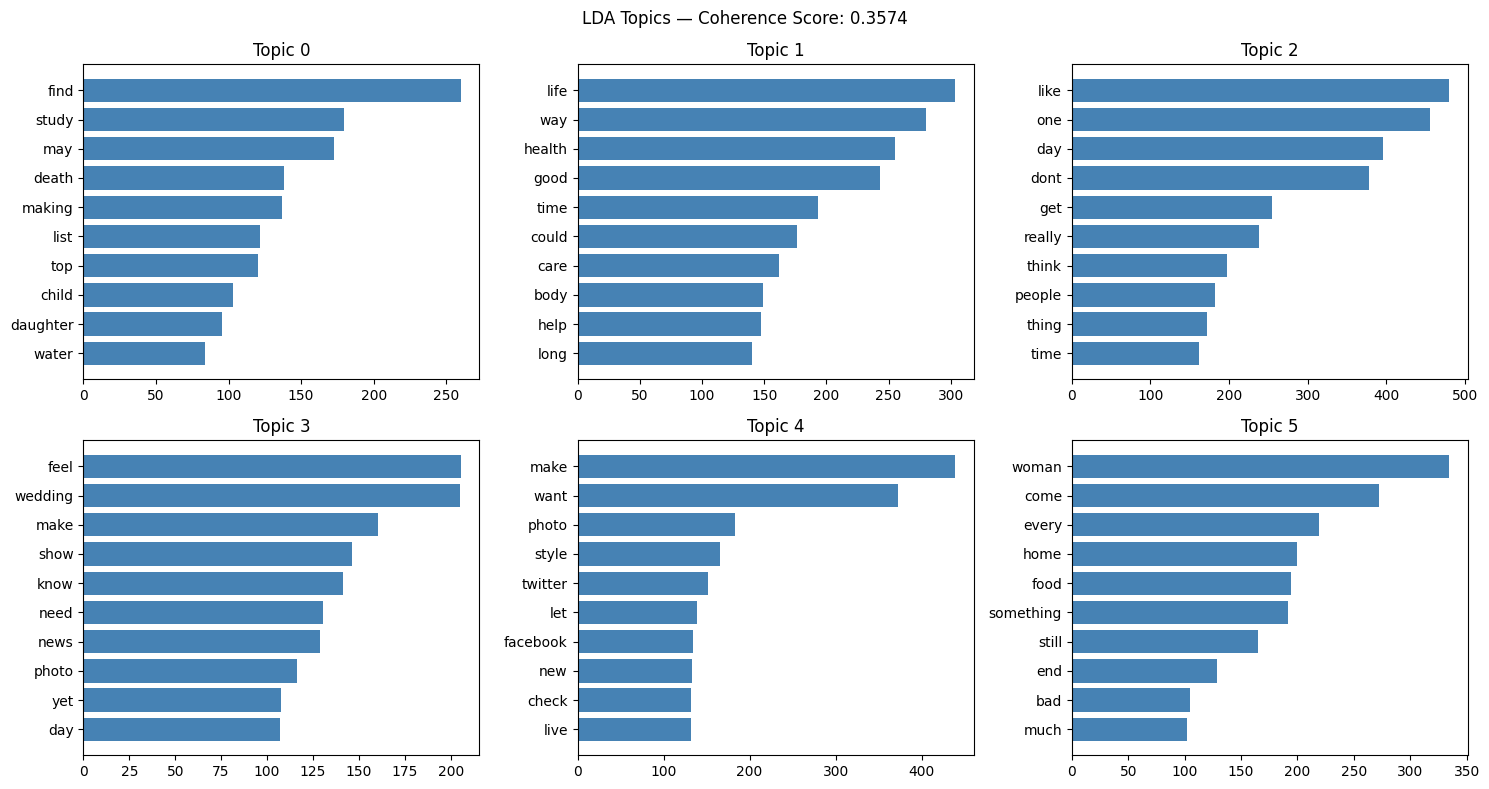

In [9]:
# Cell 9 - LDA Graph
import matplotlib.pyplot as plt
import os
os.makedirs('../graphs', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx in range(6):
    topic = lda.components_[idx]
    top_idx = topic.argsort()[-10:][::-1]
    top_w = [vocab[i] for i in top_idx]
    top_v = [topic[i] for i in top_idx]
    axes[idx].barh(top_w[::-1], top_v[::-1], color='steelblue')
    axes[idx].set_title(f'Topic {idx}')

plt.suptitle(f'LDA Topics — Coherence: {LDA_SCORE:.4f} | Perplexity: {LDA_PERPLEXITY:.4f}')
plt.tight_layout()
plt.savefig('../graphs/lda_topics.png')
plt.show()